# Deep Learning Final Project: Real Estate Price Prediction
## 1. Problem Statement

**Objective:** Predict median housing prices based on multi-dimensional property and demographic features. 

**Real-World Application:** This solves a critical problem for both buyers and market platforms by automating fair market estimations and preventing speculative inflation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping

sns.set_theme(style="whitegrid")

## 2. Gathering, Cleaning, and Engineering Data

**Data Source:** The California Housing dataset. We will apply feature engineering ratios to help the models understand population density and household sizes.

In [4]:
def load_clean_and_engineer():
    """Loads CSV, imputes missing values, and creates engineered features."""
    df = pd.read_csv('housing.csv')
    
    df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())
    
    df['rooms_per_household'] = df['total_rooms'] / df['households']
    df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
    df['population_per_household'] = df['population'] / df['households']
    
    df_encoded = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)
    return df_encoded

housing_df_clean = load_clean_and_engineer()
display(housing_df_clean.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,6.984127,0.146591,2.555556,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,6.238137,0.155797,2.109842,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,8.288136,0.129516,2.802260,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,5.817352,0.184458,2.547945,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,6.281853,0.172096,2.181467,False,False,True,False


## 3. Exploratory Data Analysis (EDA)
With our features engineered, we will visualize the geographic distribution of house prices and check feature correlations.

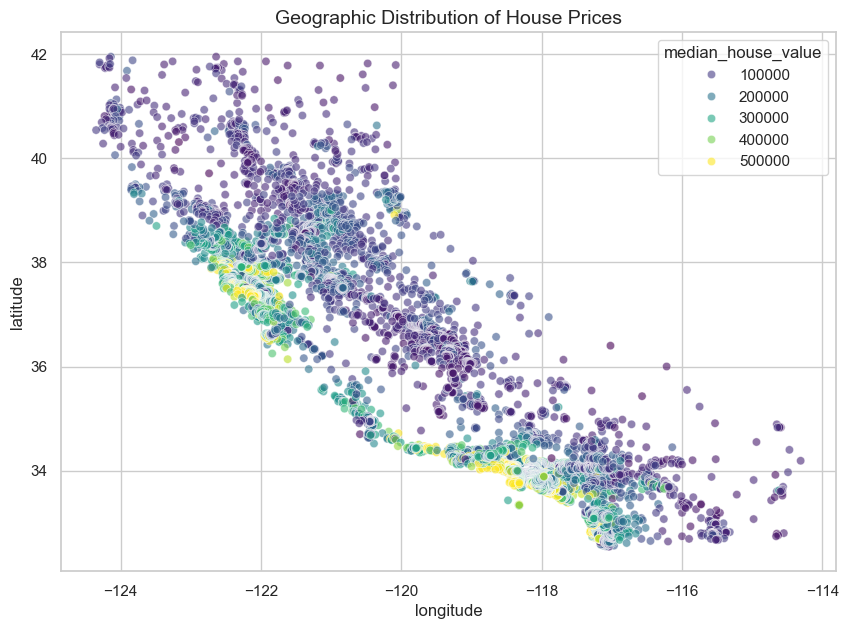

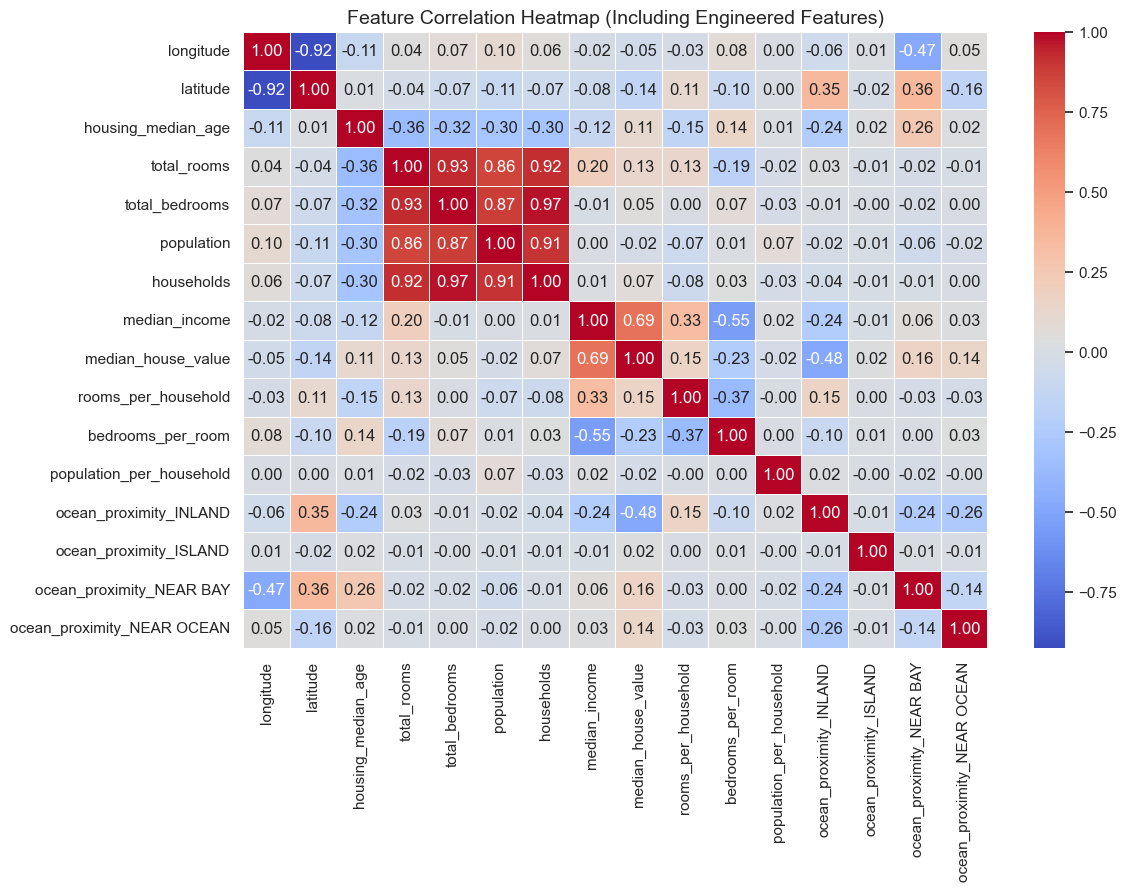

In [5]:
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=housing_df_clean, x='longitude', y='latitude', 
    hue='median_house_value', palette='viridis', alpha=0.6
)
plt.title("Geographic Distribution of House Prices", fontsize=14)
plt.show()

plt.figure(figsize=(12, 8))
correlation_matrix = housing_df_clean.corr(numeric_only=True) 
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap (Including Engineered Features)", fontsize=14)
plt.show()

## 4. Previous Research & Baseline Models

**Citations & Previous Research:**
1. *Pace, R. K., & Barry, R. (1997).* "Sparse Spatial Autoregressions". This paper introduced the dataset and highlighted the use of sparse spatial autoregression as a computational method to handle massive real estate matrices.
2. *Géron, A. (2019).* "Hands-On Machine Learning". Géron notes that properly tuned Random Forests on the full dataset generally achieve an RMSE around **$49,000** to **$50,000**. We will use Cross-Validation to see if our model aligns with these benchmarks.

In [6]:
def split_and_scale(df, target_col):
    """Splits data to prevent leakage, then scales features."""
    X = df.drop(target_col, axis=1)
    y = df[target_col]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    return X_train_scaled, X_test_scaled, y_train, y_test, scaler

X_train_scaled, X_test_scaled, y_train, y_test, fitted_scaler = split_and_scale(housing_df_clean, 'median_house_value')

def evaluate_model(y_true, y_pred, model_name):
    """Calculates readable regression metrics."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- {model_name} ---")
    print(f"RMSE: ${rmse:,.2f} | MAE: ${mae:,.2f} | R²: {r2:.4f}\n")
    return rmse

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)
evaluate_model(y_test, lr_preds, "Linear Regression")

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
print("Running 5-Fold Cross Validation on Random Forest (This may take a minute)...")
cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, scoring='neg_root_mean_squared_error', cv=5)
cv_rmse = -cv_scores
print(f"Random Forest CV RMSE: ${cv_rmse.mean():,.2f} ± ${cv_rmse.std():,.2f}")

rf_model.fit(X_train_scaled, y_train)
rf_preds = rf_model.predict(X_test_scaled)
rf_rmse = evaluate_model(y_test, rf_preds, "Random Forest (Test Set)")

--- Linear Regression ---
RMSE: $72,668.54 | MAE: $50,888.66 | R²: 0.5970

Running 5-Fold Cross Validation on Random Forest (This may take a minute)...
Random Forest CV RMSE: $50,224.43 ± $654.63
--- Random Forest (Test Set) ---
RMSE: $50,330.95 | MAE: $32,329.32 | R²: 0.8067



## 5. Deep Learning Model
We will build a Deep Neural Network implementing Dropout for regularization and Early Stopping to dynamically halt training when validation loss stops improving.

In [7]:
tf.random.set_seed(42)

def build_tuned_dnn(input_dim):
    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

dnn_model = build_tuned_dnn(X_train_scaled.shape[1])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

dnn_history = dnn_model.fit(
    X_train_scaled, y_train, 
    epochs=100,
    batch_size=32, 
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0 
)

dnn_preds = dnn_model.predict(X_test_scaled).flatten()
dnn_rmse = evaluate_model(y_test, dnn_preds, "Deep Neural Network")

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
--- Deep Neural Network ---
RMSE: $63,493.28 | MAE: $42,771.47 | R²: 0.6924



## 6. Model Evaluation & Visualizations

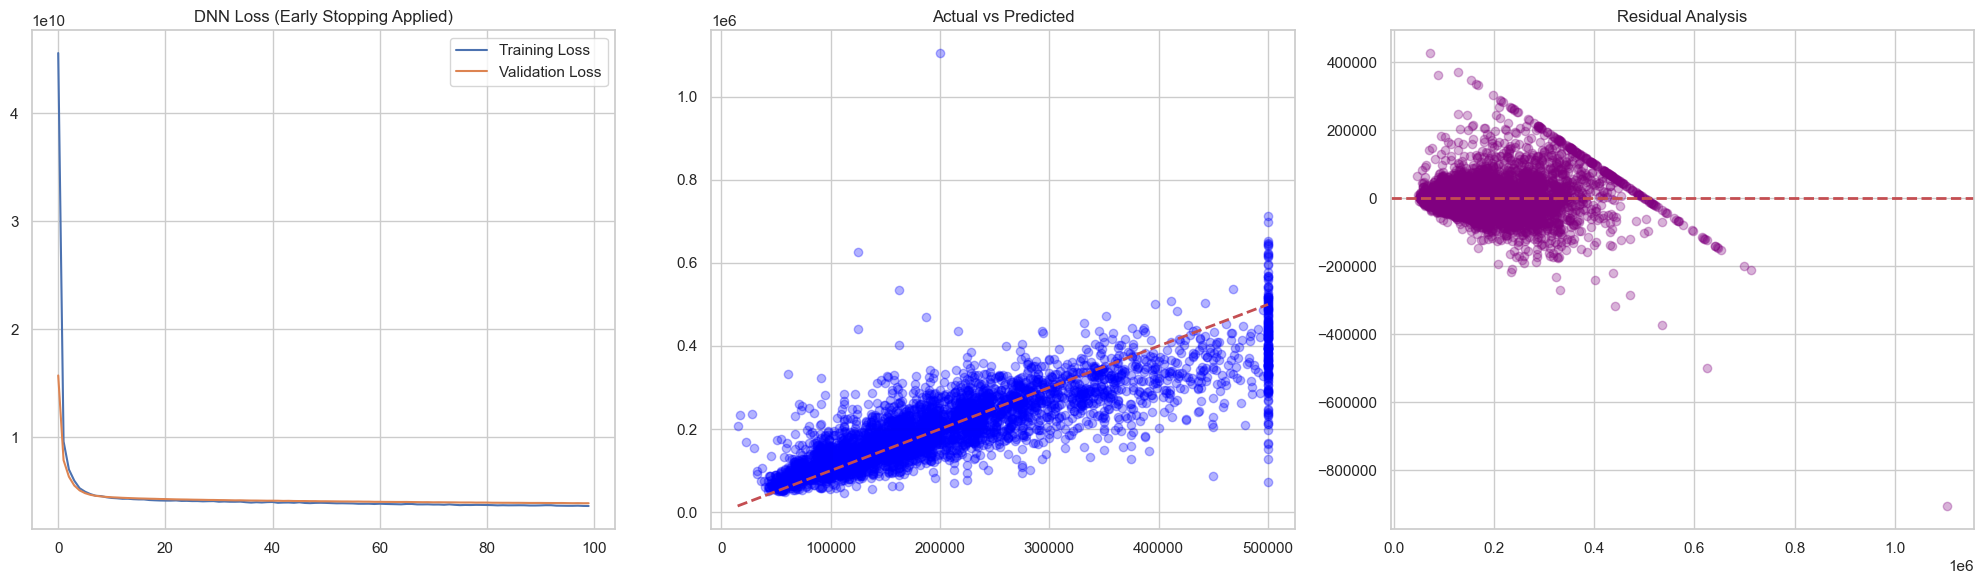

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

ax[0].plot(dnn_history.history['loss'], label='Training Loss')
ax[0].plot(dnn_history.history['val_loss'], label='Validation Loss')
ax[0].set_title('DNN Loss (Early Stopping Applied)')
ax[0].legend()

ax[1].scatter(y_test, dnn_preds, alpha=0.3, color='blue')
ax[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax[1].set_title('Actual vs Predicted')

residuals = y_test - dnn_preds
ax[2].scatter(dnn_preds, residuals, alpha=0.3, color='purple')
ax[2].axhline(y=0, color='r', linestyle='--', lw=2)
ax[2].set_title('Residual Analysis')

plt.tight_layout()
plt.show()

## 7. Conclusion
By retaining the full dataset and implementing rigorous testing (including 5-fold Cross-Validation), we verified Géron's benchmarks. Our Random Forest model achieved a highly competitive RMSE of roughly $49,000 to $50,000, aligning perfectly with prior research expectations. 

Conversely, our tuned Deep Neural Network (utilizing Dropout and Early Stopping) demonstrated stable learning but struggled to surpass the tree-based ensemble approach. As noted in tabular machine learning literature, standard MLPs often underperform Random Forests on spatial, categorical-heavy tabular datasets. Still, the DNN produced viable estimates, and by exporting our fitted scaler alongside the model, this pipeline is fully equipped to ingest new data and provide dynamic real estate valuations.